In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Dataset Structure
The dataset is organized into three folds: fold1, fold2, and fold3, consistent with the original dataset structure. Each fold contains data in a tabular format with the following four columns:

image: The RGB tile of the sample.
instances: A list of nuclei instances. Each instance represents exactly one nucleus and is in binary format (1 - nucleus, 0 - background)
categories: An integer class label for each nucleus, corresponding to one of the following categories:

1. Neoplastic
2. Inflammatory
3. Connective
4. Dead
5. Epithelial

tissue: The integer tissue type from which the sample originates, belonging to one of these categories:

1. Adrenal Gland
2. Bile Duct
3. Bladder
4. Breast
5. Cervix
6. Colon
7. Esophagus
8. Head & Neck
9. Kidney
10. Liver
11. Lung
12. Ovarian
13. Pancreatic
14. Prostate
15. Skin
16. Stomach
17. Testis
18. Thyroid
19. Uterus


In [2]:
!pip install datasets

In [3]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
dataset = load_dataset("RationAI/PanNuke")

README.md:   0%|          | 0.00/4.49k [00:00<?, ?B/s]

fold1-00000-of-00001.parquet:   0%|          | 0.00/280M [00:00<?, ?B/s]

fold2-00000-of-00001.parquet:   0%|          | 0.00/264M [00:00<?, ?B/s]

fold3-00000-of-00001.parquet:   0%|          | 0.00/289M [00:00<?, ?B/s]

Generating fold1 split:   0%|          | 0/2656 [00:00<?, ? examples/s]

Generating fold2 split:   0%|          | 0/2523 [00:00<?, ? examples/s]

Generating fold3 split:   0%|          | 0/2722 [00:00<?, ? examples/s]

In [5]:
print(dataset)

DatasetDict({
    fold1: Dataset({
        features: ['image', 'instances', 'categories', 'tissue'],
        num_rows: 2656
    })
    fold2: Dataset({
        features: ['image', 'instances', 'categories', 'tissue'],
        num_rows: 2523
    })
    fold3: Dataset({
        features: ['image', 'instances', 'categories', 'tissue'],
        num_rows: 2722
    })
})


In [6]:
# Step 5: Access a specific fold (e.g., fold1)
fold1 = dataset['fold1']

# Step 6: Display the features of the dataset
print("Features in fold1:", fold1.features)

# Step 7: Explore the first sample in fold1
sample = fold1[0]
print("Sample keys:", sample.keys())

# Get image and instances
image = sample['image']
instances = sample['instances']  # This is a list of PIL images (masks)
categories = sample['categories']
tissue = sample['tissue']

# Print image and instances information
print("Image size (width, height):", image.size)
print("Number of instance masks:", len(instances))
print("Categories:", categories)
print("Tissue type:", tissue)


Features in fold1: {'image': Image(mode='RGB', decode=True, id=None), 'instances': Sequence(feature=Image(mode='1', decode=True, id=None), length=-1, id=None), 'categories': Sequence(feature=ClassLabel(names=['Neoplastic', 'Inflammatory', 'Connective', 'Dead', 'Epithelial'], id=None), length=-1, id=None), 'tissue': ClassLabel(names=['Adrenal Gland', 'Bile Duct', 'Bladder', 'Breast', 'Cervix', 'Colon', 'Esophagus', 'Head & Neck', 'Kidney', 'Liver', 'Lung', 'Ovarian', 'Pancreatic', 'Prostate', 'Skin', 'Stomach', 'Testis', 'Thyroid', 'Uterus'], id=None)}
Sample keys: dict_keys(['image', 'instances', 'categories', 'tissue'])
Image size (width, height): (256, 256)
Number of instance masks: 8
Categories: [0, 0, 0, 0, 1, 1, 2, 2]
Tissue type: 3


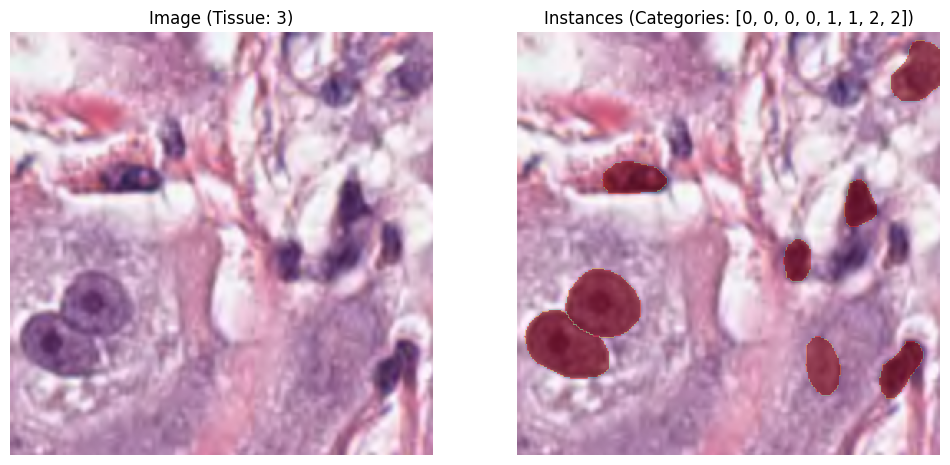

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data
image = sample['image']  # PIL Image (256x256 RGB)
instances = sample['instances']  # List of 8 binary masks (PIL Images)
categories = sample['categories']  # List of category labels [0, 0, 0, 0, 1, 1, 2, 2]
tissue = sample['tissue']  # Tissue type (3 = 'Breast')

# Convert image to NumPy array
image_np = np.array(image)

# Create a combined mask for visualization
combined_mask = np.zeros_like(image_np[:, :, 0], dtype=np.uint8)  # Single channel
for i, mask in enumerate(instances):
    mask_np = np.array(mask, dtype=np.uint8)  # Ensure mask is uint8
    combined_mask += mask_np * (i + 1)  # Assign unique values to each mask

# Map categories to colors
category_colors = {
    0: 'red',  # Neoplastic
    1: 'green',  # Inflammatory
    2: 'blue',  # Connective
    3: 'yellow',  # Dead
    4: 'purple'  # Epithelial
}

# Visualize the image and masks
plt.figure(figsize=(12, 6))

# Plot the image
plt.subplot(1, 2, 1)
plt.imshow(image_np)
plt.title(f"Image (Tissue: {tissue})")
plt.axis('off')

# Plot the instances with category colors
plt.subplot(1, 2, 2)
plt.imshow(image_np)
for i, mask in enumerate(instances):
    mask_np = np.array(mask, dtype=np.uint8)  # Ensure mask is uint8
    plt.imshow(mask_np, cmap='jet', alpha=0.5 * mask_np, vmin=0, vmax=1)
plt.title(f"Instances (Categories: {categories})")
plt.axis('off')

plt.show()

In [8]:
np.unique(combined_mask)

array([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=uint8)

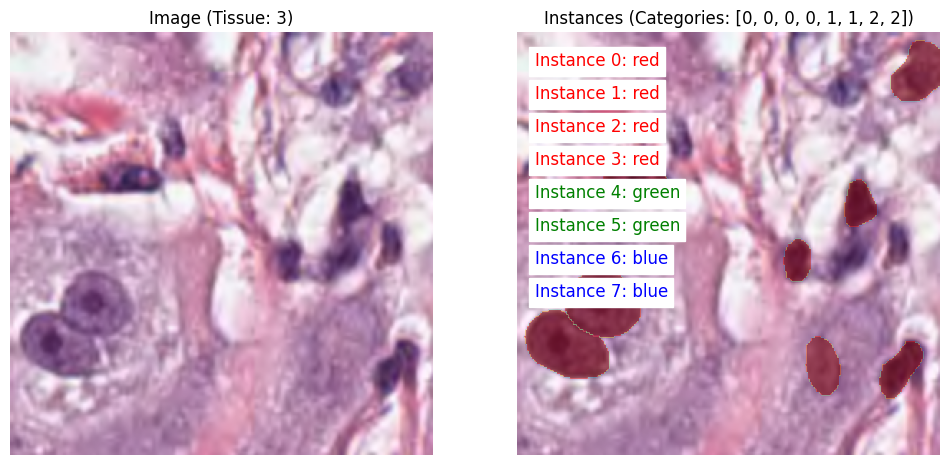

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data
image = sample['image']  # PIL Image (256x256 RGB)
instances = sample['instances']  # List of 8 binary masks (PIL Images)
categories = sample['categories']  # List of category labels [0, 0, 0, 0, 1, 1, 2, 2]
tissue = sample['tissue']  # Tissue type (3 = 'Breast')

# Convert image to NumPy array
image_np = np.array(image)

# Map categories to colors
category_colors = {
    0: 'red',  # Neoplastic
    1: 'green',  # Inflammatory
    2: 'blue',  # Connective
    3: 'yellow',  # Dead
    4: 'purple'  # Epithelial
}

# Visualize the image and masks
plt.figure(figsize=(12, 6))

# Plot the image
plt.subplot(1, 2, 1)
plt.imshow(image_np)
plt.title(f"Image (Tissue: {tissue})")
plt.axis('off')

# Plot the instances with category colors
plt.subplot(1, 2, 2)
plt.imshow(image_np)
for i, (mask, category) in enumerate(zip(instances, categories)):
    mask_np = np.array(mask, dtype=np.uint8)  # Convert mask to NumPy array
    color = category_colors[category]  # Get color for the category
    plt.imshow(mask_np, cmap='jet', alpha=0.5 * mask_np, vmin=0, vmax=1)
    plt.text(10, 20 + i * 20, f"Instance {i}: {category_colors[category]}", color=color, fontsize=12, backgroundcolor='white')
plt.title(f"Instances (Categories: {categories})")
plt.axis('off')

plt.show()